In [22]:
# CELL 1

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from api.process_ai.process.pipeline.process_configs import get_process_config
from api.process_ai.process.pipeline.orchestrator import (
    TrainParams,
    train_process_from_key,
)
from api.process_ai.process.core.inference import (
    load_process_artifacts,
    analyze_batch,
)

In [23]:
# CELL 2

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "api").exists() and (p / "model").exists():
            return p
    raise FileNotFoundError("Could not find project root")

def to_abs_path(path_like: str | Path, project_root: Path) -> Path:
    p = Path(path_like)
    return p if p.is_absolute() else (project_root / p).resolve()

PROJECT_ROOT = find_project_root()

PROCESS_KEY = "customs"
cfg = get_process_config(PROCESS_KEY)
PROCESS_CODE = cfg.process_code

DATA_DIR = to_abs_path(cfg.data_dir, PROJECT_ROOT)
REGISTRY_DIR = to_abs_path(cfg.registry_dir, PROJECT_ROOT)
MODEL_DIR = to_abs_path(cfg.model_dir, PROJECT_ROOT)
REPORT_DIR = to_abs_path(cfg.report_dir, PROJECT_ROOT)

EVENTS_PATH = DATA_DIR / "events.csv"
CONTEXT_PATH = DATA_DIR / "cases_context.csv"

EXPERIMENT_MODEL_DIR = MODEL_DIR.parent / "process_models_experiments"
EXPERIMENT_MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT         :", PROJECT_ROOT)
print("PROCESS_KEY          :", PROCESS_KEY)
print("PROCESS_CODE         :", PROCESS_CODE)
print("DATA_DIR             :", DATA_DIR)
print("REGISTRY_DIR         :", REGISTRY_DIR)
print("MODEL_DIR            :", MODEL_DIR)
print("REPORT_DIR           :", REPORT_DIR)
print("EXPERIMENT_MODEL_DIR :", EXPERIMENT_MODEL_DIR)

PROJECT_ROOT         : D:\logistics_AI
PROCESS_KEY          : customs
PROCESS_CODE         : IMPORT_CUSTOMS_CLEARANCE
DATA_DIR             : D:\logistics_AI\data\synth_optimal_3process_v1
REGISTRY_DIR         : D:\logistics_AI\data\synth_optimal_3process_v1\registry
MODEL_DIR            : D:\logistics_AI\model\process_models
REPORT_DIR           : D:\logistics_AI\reports\customs
EXPERIMENT_MODEL_DIR : D:\logistics_AI\model\process_models_experiments


In [24]:
# CELL 3

PRIMARY = "#1f4e79"
SECONDARY = "#5b9bd5"
ACCENT = "#9dc3e6"
GRID = "#d9d9d9"
TEXT = "#222222"

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.labelcolor"] = TEXT
plt.rcParams["xtick.color"] = TEXT
plt.rcParams["ytick.color"] = TEXT
plt.rcParams["text.color"] = TEXT
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

def pretty_step_label(x: str) -> str:
    x = str(x)
    x = x.replace("STEP_", "")
    parts = x.split("_", 1)
    if len(parts) == 2 and parts[0].isdigit():
        x = parts[1]
    x = x.replace("_", " ").title()
    return x[:32] + "..." if len(x) > 32 else x

def style_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.grid(axis=grid_axis, color=GRID, linestyle="-", linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)

def save_and_show(fig, path: Path):
    fig.tight_layout()
    fig.savefig(path, dpi=240, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved:", path)

In [25]:
# CELL 4

events_df = pd.read_csv(EVENTS_PATH)
events_df = events_df[events_df["process_code"].astype(str) == PROCESS_CODE].copy()

print("events_df shape:", events_df.shape)
display(events_df.head())

events_df shape: (68576, 5)


,process_code,case_id,step_code,start_time,end_time
179,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_001_DOC_RECEIVED,2025-05-26T12:16:59,2025-05-26T12:41:58
180,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_002_DOC_VALIDATION,2025-05-26T12:41:58,2025-05-26T12:53:24
181,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_003_HS_CLASSIFICATION,2025-05-26T12:53:24,2025-05-26T13:11:02
182,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_004_SUBMIT_DECLARATION,2025-05-26T13:11:02,2025-05-26T13:35:45
183,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_005_RISK_CHANNELING,2025-05-26T13:35:45,2025-05-26T13:43:44


In [26]:
# CELL 5

experiment_params = [
    TrainParams(n_estimators=150, contamination=0.04, random_state=42),
    TrainParams(n_estimators=200, contamination=0.06, random_state=42),
    TrainParams(n_estimators=300, contamination=0.06, random_state=42),
    TrainParams(n_estimators=300, contamination=0.08, random_state=42),
]

experiment_params

[TrainParams(events_filename='events.csv', context_filename='cases_context.csv', include_context_numeric=False, n_estimators=150, contamination=0.04, random_state=42, allow_unknown_steps=False),
 TrainParams(events_filename='events.csv', context_filename='cases_context.csv', include_context_numeric=False, n_estimators=200, contamination=0.06, random_state=42, allow_unknown_steps=False),
 TrainParams(events_filename='events.csv', context_filename='cases_context.csv', include_context_numeric=False, n_estimators=300, contamination=0.06, random_state=42, allow_unknown_steps=False),
 TrainParams(events_filename='events.csv', context_filename='cases_context.csv', include_context_numeric=False, n_estimators=300, contamination=0.08, random_state=42, allow_unknown_steps=False)]

In [27]:
# CELL 6

experiment_rows = []

for params in experiment_params:
    train_res = train_process_from_key(
        PROCESS_KEY,
        params=params,
        data_dir=str(DATA_DIR),
        registry_dir=str(REGISTRY_DIR),
        model_root_dir=str(EXPERIMENT_MODEL_DIR),
    )

    art = load_process_artifacts(
        process_code=PROCESS_CODE,
        model_root_dir=EXPERIMENT_MODEL_DIR,
        registry_dir=REGISTRY_DIR,
    )

    batch_out = analyze_batch(
        events_df,
        artifacts=art,
        allow_unknown_steps=False,
        max_cases=1500,
    )

    ok_eval_rows = [r for r in batch_out["results"] if r.get("ok")]
    eval_scores = [r.get("risk_score", np.nan) for r in ok_eval_rows]
    eval_scores = [x for x in eval_scores if pd.notna(x)]

    high_risk_count_eval = int(sum(x >= 80 for x in eval_scores)) if eval_scores else 0
    high_risk_rate_eval = float(high_risk_count_eval / len(eval_scores)) if eval_scores else 0.0

    experiment_rows.append({
        "n_estimators": params.n_estimators,
        "contamination": params.contamination,
        "random_state": params.random_state,
        "cases_used_train": train_res["train_summary"]["cases_used"],
        "events_rows_used": train_res["train_summary"]["events_rows_used"],
        "cases_analyzed_eval": batch_out["summary"]["cases_analyzed"],
        "cases_ok_eval": batch_out["summary"]["cases_ok"],
        "avg_risk_eval": batch_out["summary"]["avg_risk"],
        "p95_risk_eval": batch_out["summary"]["p95_risk"],
        "high_risk_count_eval": high_risk_count_eval,
        "high_risk_rate_eval": high_risk_rate_eval,
    })

experiment_df = pd.DataFrame(experiment_rows).sort_values(
    ["high_risk_rate_eval", "avg_risk_eval"], ascending=False
)

experiment_df["param_label"] = experiment_df.apply(
    lambda r: f"n={int(r['n_estimators'])} | c={r['contamination']:.02f}",
    axis=1,
)

display(experiment_df)

,n_estimators,contamination,random_state,cases_used_train,events_rows_used,cases_analyzed_eval,cases_ok_eval,avg_risk_eval,p95_risk_eval,high_risk_count_eval,high_risk_rate_eval,param_label
0,150,0.04,42,4286,68576,1500,1500,50.235333,94.0,304,0.202667,n=150 | c=0.04
1,200,0.06,42,4286,68576,1500,1500,50.238000,94.0,303,0.202000,n=200 | c=0.06
2,300,0.06,42,4286,68576,1500,1500,50.241333,94.0,297,0.198000,n=300 | c=0.06
3,300,0.08,42,4286,68576,1500,1500,50.241333,94.0,297,0.198000,n=300 | c=0.08


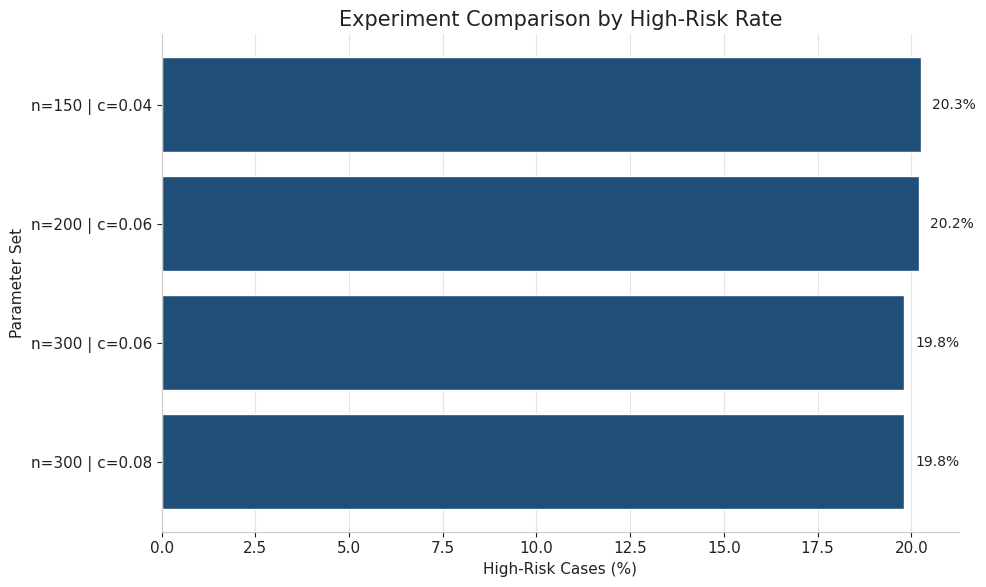

Saved: D:\logistics_AI\reports\customs\customs_experiment_compare_high_risk_rate.png


In [28]:
# CELL 7

plot_df = experiment_df.sort_values("high_risk_rate_eval", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_df["param_label"], plot_df["high_risk_rate_eval"] * 100, color=PRIMARY, edgecolor="white")
ax.set_title("Experiment Comparison by High-Risk Rate")
ax.set_xlabel("High-Risk Cases (%)")
ax.set_ylabel("Parameter Set")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2, f"{w:.1f}%", va="center", ha="left", fontsize=10)

experiment_compare_path = REPORT_DIR / f"{PROCESS_KEY}_experiment_compare_high_risk_rate.png"
save_and_show(fig, experiment_compare_path)

In [29]:
# CELL 8

FINAL_PARAMS = TrainParams(
    n_estimators=300,
    contamination=0.06,
    random_state=42,
)

print(FINAL_PARAMS)

TrainParams(events_filename='events.csv', context_filename='cases_context.csv', include_context_numeric=False, n_estimators=300, contamination=0.06, random_state=42, allow_unknown_steps=False)


In [30]:
# CELL 9

final_train_res = train_process_from_key(
    PROCESS_KEY,
    params=FINAL_PARAMS,
    data_dir=str(DATA_DIR),
    registry_dir=str(REGISTRY_DIR),
    model_root_dir=str(MODEL_DIR),
)

final_train_summary = final_train_res["train_summary"]

display(pd.DataFrame([final_train_summary]))

,process_code,events_rows_used,cases_used,include_context_numeric,n_estimators,contamination,random_state,artifacts_dir,validation_warnings,feature_report
0,IMPORT_CUSTOMS_CLEARANCE,68576,4286,False,300,0.06,42,D:\logistics_AI\model\process_models\IMPORT_CU...,[],"{'cases': 4286, 'dropped_cases': 0, 'repeated_..."


In [31]:
# CELL 10

artifacts = load_process_artifacts(
    process_code=PROCESS_CODE,
    model_root_dir=MODEL_DIR,
    registry_dir=REGISTRY_DIR,
)

print("Loaded artifacts for:", artifacts.process_code)
print("Number of step codes:", len(artifacts.step_codes))
print("Schema keys:", list(artifacts.schema.keys()))

Loaded artifacts for: IMPORT_CUSTOMS_CLEARANCE
Number of step codes: 16
Schema keys: ['step_codes', 'step_feature_cols', 'all_feature_cols']


In [32]:
# CELL 11

events_eval_df = events_df.copy()

events_eval_df["start_time"] = pd.to_datetime(
    events_eval_df["start_time"],
    errors="coerce",
)
events_eval_df["end_time"] = pd.to_datetime(
    events_eval_df["end_time"],
    errors="coerce",
)

bad_start = int(events_eval_df["start_time"].isna().sum())
bad_end = int(events_eval_df["end_time"].isna().sum())

print("Bad start_time rows:", bad_start)
print("Bad end_time rows  :", bad_end)

if bad_start > 0 or bad_end > 0:
    events_eval_df = events_eval_df.dropna(subset=["start_time", "end_time"]).copy()

print("events_eval_df shape after datetime cleanup:", events_eval_df.shape)

batch_out = analyze_batch(
    events_eval_df,
    artifacts=artifacts,
    allow_unknown_steps=False,
    max_cases=None,
)

summary_payload = batch_out["summary"]

ok_rows = []
for r in batch_out["results"]:
    if not r.get("ok"):
        continue

    top1 = r["top_steps"][0] if r.get("top_steps") else {}

    ok_rows.append({
        "process_code": r.get("process_code"),
        "case_id": r.get("case_id"),
        "risk_score": r.get("risk_score"),
        "anomaly_score": r.get("raw_anomaly"),
        "overall_severity": r.get("overall_severity"),
        "top_step_name": top1.get("step_code"),
        "top_step_duration_min": top1.get("duration_min"),
        "top_step_p95": top1.get("p95"),
        "top_step_deviation_p95": top1.get("deviation_factor"),
        "top_step_zscore": top1.get("z_score"),
        "top_step_severity": top1.get("severity"),
        "validation_warnings": r.get("validation_warnings"),
    })

results_df = pd.DataFrame(ok_rows).copy()

print("summary_payload:")
print(summary_payload)

print("\nresults_df shape:", results_df.shape)
display(results_df.head())

summary_payload:
{'process_code': 'IMPORT_CUSTOMS_CLEARANCE', 'cases_analyzed': 4286, 'cases_ok': 4286, 'avg_risk': 49.500699953336444, 'p95_risk': 94.75}

results_df shape: (4286, 12)


,process_code,case_id,risk_score,anomaly_score,overall_severity,top_step_name,top_step_duration_min,top_step_p95,top_step_deviation_p95,top_step_zscore,top_step_severity,validation_warnings
0,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,31.0,0.404765,NORMAL,STEP_013_CARGO_RELEASED,679.900,611.192,1.112,2.309,WATCHLIST,[]
1,IMPORT_CUSTOMS_CLEARANCE,ORD_6304046335,57.0,0.424179,NORMAL,STEP_001_DOC_RECEIVED,52.500,47.446,1.107,2.260,WATCHLIST,[]
2,IMPORT_CUSTOMS_CLEARANCE,ORD_6642385052,19.0,0.396271,NORMAL,STEP_016_CUSTOMS_CLOSEOUT,33.583,48.433,0.693,0.767,NORMAL,[]
3,IMPORT_CUSTOMS_CLEARANCE,ORD_8452237344,3.0,0.380712,NORMAL,STEP_010_PAYMENT_CONFIRMED,362.717,441.608,0.821,1.189,NORMAL,[]
4,IMPORT_CUSTOMS_CLEARANCE,ORD_5031563635,26.0,0.400991,NORMAL,STEP_016_CUSTOMS_CLOSEOUT,33.900,48.433,0.700,0.790,NORMAL,[]


Bad start_time rows: 0
Bad end_time rows  : 0
events_eval_df shape after datetime cleanup: (68576, 5)
summary_payload:
{'process_code': 'IMPORT_CUSTOMS_CLEARANCE', 'cases_analyzed': 4286, 'cases_ok': 4286, 'avg_risk': 49.500699953336444, 'p95_risk': 94.75}

results_df shape: (4286, 12)


,process_code,case_id,risk_score,anomaly_score,overall_severity,top_step_name,top_step_duration_min,top_step_p95,top_step_deviation_p95,top_step_zscore,top_step_severity,validation_warnings
0,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,31.0,0.404765,NORMAL,STEP_013_CARGO_RELEASED,679.900,611.192,1.112,2.309,WATCHLIST,[]
1,IMPORT_CUSTOMS_CLEARANCE,ORD_6304046335,57.0,0.424179,NORMAL,STEP_001_DOC_RECEIVED,52.500,47.446,1.107,2.260,WATCHLIST,[]
2,IMPORT_CUSTOMS_CLEARANCE,ORD_6642385052,19.0,0.396271,NORMAL,STEP_016_CUSTOMS_CLOSEOUT,33.583,48.433,0.693,0.767,NORMAL,[]
3,IMPORT_CUSTOMS_CLEARANCE,ORD_8452237344,3.0,0.380712,NORMAL,STEP_010_PAYMENT_CONFIRMED,362.717,441.608,0.821,1.189,NORMAL,[]
4,IMPORT_CUSTOMS_CLEARANCE,ORD_5031563635,26.0,0.400991,NORMAL,STEP_016_CUSTOMS_CLOSEOUT,33.900,48.433,0.700,0.790,NORMAL,[]


In [33]:
# CELL 12

summary_df = pd.DataFrame([{
    "process_code": PROCESS_CODE,
    "cases_analyzed": int(summary_payload["cases_analyzed"]),
    "cases_ok": int(summary_payload["cases_ok"]),
    "avg_risk": float(summary_payload["avg_risk"]),
    "p95_risk": float(summary_payload["p95_risk"]),
    "high_risk_cases_80plus": int((results_df["risk_score"] >= 80).sum()),
    "high_risk_rate_80plus": float((results_df["risk_score"] >= 80).mean()),
    "avg_top_step_duration_min": float(results_df["top_step_duration_min"].mean()),
    "avg_top_step_deviation_p95": float(results_df["top_step_deviation_p95"].mean()),
}])

display(summary_df)

,process_code,cases_analyzed,cases_ok,avg_risk,p95_risk,high_risk_cases_80plus,high_risk_rate_80plus,avg_top_step_duration_min,avg_top_step_deviation_p95
0,IMPORT_CUSTOMS_CLEARANCE,4286,4286,49.5007,94.75,858,0.200187,409.51482,1.117738


In [34]:
# CELL 12.5

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use("default")

Severity distribution:
severity_native
NORMAL        2242
BOTTLENECK    1135
CRITICAL       471
ELEVATED       348
WATCHLIST       90
Name: count, dtype: int64


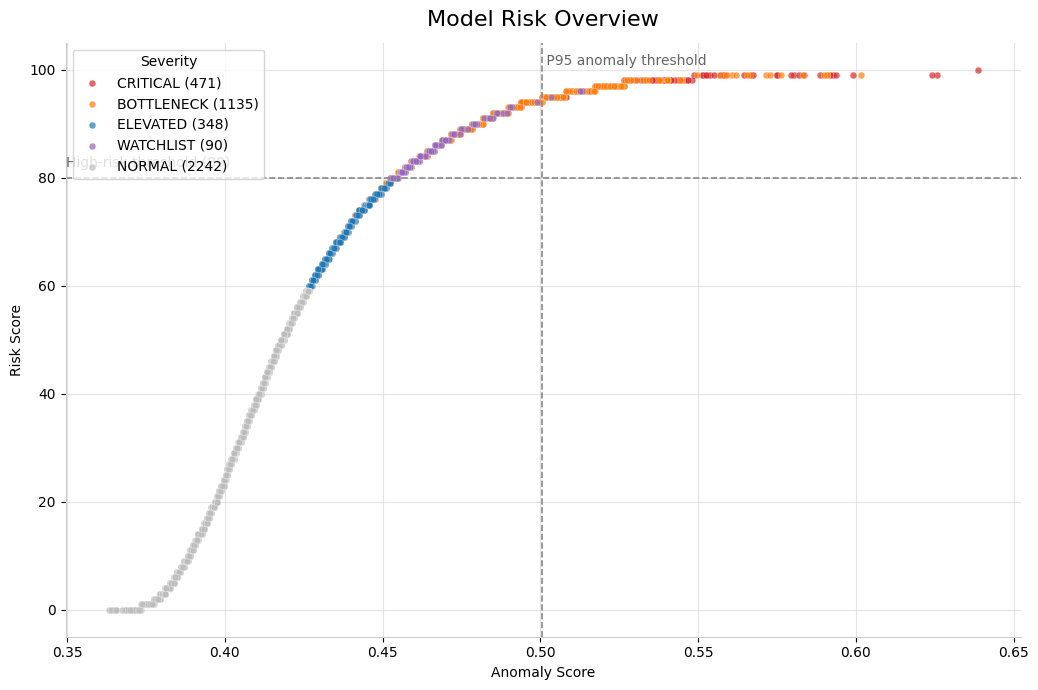

Saved: D:\logistics_AI\reports\customs\customs_model_risk_overview.png


In [35]:
# CELL 13

score_col = "anomaly_score" if "anomaly_score" in results_df.columns else "raw_anomaly"

severity_order = ["CRITICAL", "BOTTLENECK", "ELEVATED", "WATCHLIST", "NORMAL"]
color_map = {
    "CRITICAL": "#d62728",
    "BOTTLENECK": "#ff7f0e",
    "ELEVATED": "#1f77b4",
    "WATCHLIST": "#9467bd",
    "NORMAL": "#bdbdbd",
}

plot_df = results_df.copy()
plot_df[score_col] = pd.to_numeric(plot_df[score_col], errors="coerce")
plot_df["risk_score"] = pd.to_numeric(plot_df["risk_score"], errors="coerce")
plot_df["severity_native"] = plot_df["overall_severity"].astype(str).str.strip().str.upper()

plot_df = plot_df.dropna(subset=[score_col, "risk_score"]).copy()

print("Severity distribution:")
print(plot_df["severity_native"].value_counts(dropna=False))

x_thr = plot_df[score_col].quantile(0.95)
y_thr = 80.0

fig, ax = plt.subplots(figsize=(10.5, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for sev in severity_order:
    part = plot_df[plot_df["severity_native"] == sev]
    if part.empty:
        continue

    ax.scatter(
        part[score_col],
        part["risk_score"],
        s=24,
        alpha=0.70,
        c=color_map[sev],
        label=f"{sev} ({len(part)})",
        edgecolors="white",
        linewidths=0.25,
    )

ax.axhline(y_thr, color="#888888", linestyle="--", linewidth=1.2)
ax.axvline(x_thr, color="#888888", linestyle="--", linewidth=1.2)

ax.text(
    x_thr,
    ax.get_ylim()[1] * 0.98,
    " P95 anomaly threshold",
    fontsize=10,
    color="#666666",
    ha="left",
    va="top",
)

ax.text(
    ax.get_xlim()[0],
    y_thr + 1.5,
    "High-risk threshold (80)",
    fontsize=10,
    color="#666666",
    ha="left",
    va="bottom",
)

ax.set_title("Model Risk Overview", fontsize=16, pad=12)
ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Risk Score")

style_axes(ax, grid_axis="both")
ax.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left", title="Severity")

overview_path = REPORT_DIR / f"{PROCESS_KEY}_model_risk_overview.png"
save_and_show(fig, overview_path)

,severity,pct
0,CRITICAL,10.989267
1,BOTTLENECK,26.481568
2,ELEVATED,8.119459
3,WATCHLIST,2.099860
4,NORMAL,52.309846


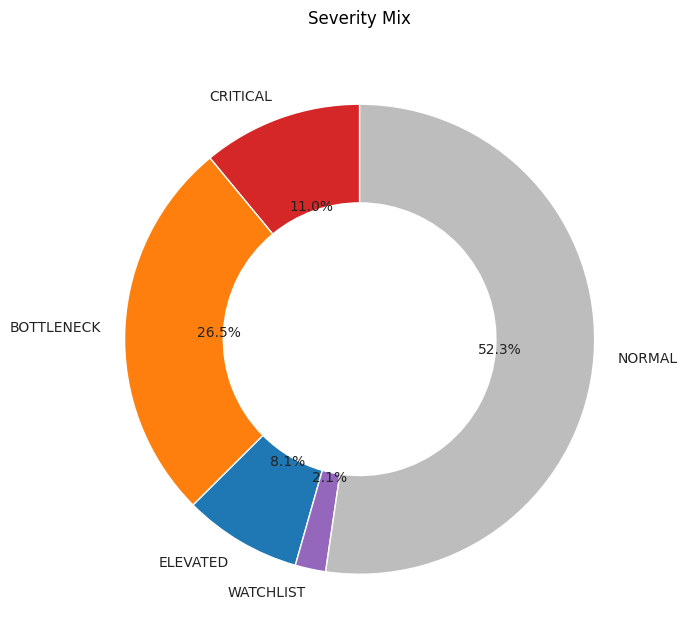

Saved: D:\logistics_AI\reports\customs\customs_severity_mix_donut.png


In [36]:
# CELL 14

severity_order = ["CRITICAL", "BOTTLENECK", "ELEVATED", "WATCHLIST", "NORMAL"]
color_map = {
    "CRITICAL": "#d62728",
    "BOTTLENECK": "#ff7f0e",
    "ELEVATED": "#1f77b4",
    "WATCHLIST": "#9467bd",
    "NORMAL": "#bdbdbd",
}

severity_df = (
    plot_df["severity_native"]
    .value_counts(normalize=True)
    .reindex(severity_order, fill_value=0)
    .mul(100)
    .reset_index()
)
severity_df.columns = ["severity", "pct"]

display(severity_df)

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

wedges, texts, autotexts = ax.pie(
    severity_df["pct"],
    labels=severity_df["severity"],
    colors=[color_map.get(x, "#bdbdbd") for x in severity_df["severity"]],
    autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"),
    textprops=dict(color="#222222", fontsize=10),
)

ax.set_title("Severity Mix", pad=16)

severity_path = REPORT_DIR / f"{PROCESS_KEY}_severity_mix_donut.png"
save_and_show(fig, severity_path)

,band,count,pct
0,0-39,1714,39.990667
1,40-59,857,19.995334
2,60-79,857,19.995334
3,80-100,858,20.018665


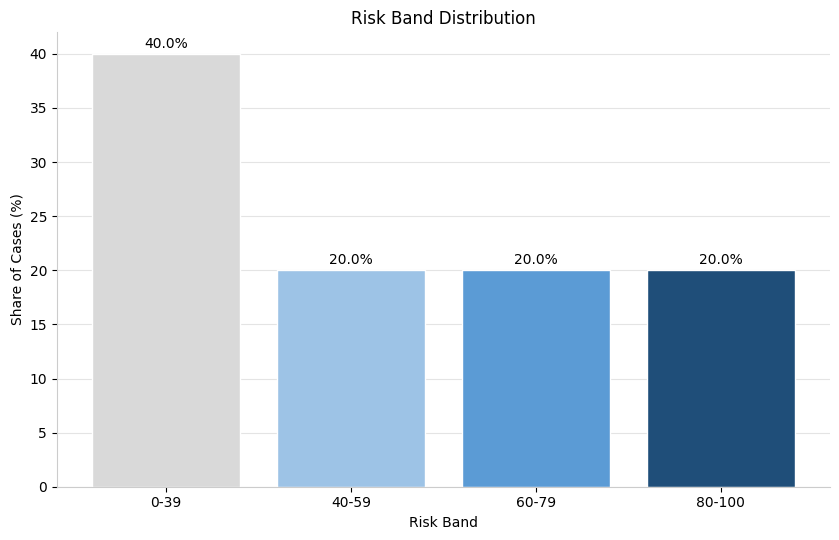

Saved: D:\logistics_AI\reports\customs\customs_risk_band_distribution.png


In [37]:
# CELL 15

risk_band_df = pd.DataFrame({
    "band": ["0-39", "40-59", "60-79", "80-100"],
    "count": [
        int(((results_df["risk_score"] >= 0) & (results_df["risk_score"] < 40)).sum()),
        int(((results_df["risk_score"] >= 40) & (results_df["risk_score"] < 60)).sum()),
        int(((results_df["risk_score"] >= 60) & (results_df["risk_score"] < 80)).sum()),
        int((results_df["risk_score"] >= 80).sum()),
    ]
})
risk_band_df["pct"] = risk_band_df["count"] / max(len(results_df), 1) * 100

display(risk_band_df)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.bar(
    risk_band_df["band"],
    risk_band_df["pct"],
    color=["#d9d9d9", "#9dc3e6", "#5b9bd5", "#1f4e79"],
    edgecolor="white",
)

ax.set_title("Risk Band Distribution")
ax.set_xlabel("Risk Band")
ax.set_ylabel("Share of Cases (%)")
style_axes(ax, grid_axis="y")

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f"{h:.1f}%", ha="center", va="bottom")

risk_band_path = REPORT_DIR / f"{PROCESS_KEY}_risk_band_distribution.png"
save_and_show(fig, risk_band_path)

,top_step_name,case_count,avg_deviation_p95,avg_duration_min,step_label
1,STEP_002_DOC_VALIDATION,297,1.165438,35.137586,Doc Validation
8,STEP_009_DUTY_TAX_INVOICE_ISSUED,266,1.149105,519.668459,Duty Tax Invoice Issued
11,STEP_012_RELEASE_ORDER_ISSUED,260,1.131731,672.215123,Release Order Issued
15,STEP_016_CUSTOMS_CLOSEOUT,257,1.128802,54.672700,Customs Closeout
12,STEP_013_CARGO_RELEASED,267,1.122543,686.099378,Cargo Released
3,STEP_004_SUBMIT_DECLARATION,276,1.117431,55.964844,Submit Declaration
10,STEP_011_CLEARANCE_APPROVED,263,1.109430,653.518650,Clearance Approved
0,STEP_001_DOC_RECEIVED,260,1.109192,52.626400,Doc Received
6,STEP_007_PHYSICAL_INSPECTION_COMPLETE,244,1.092320,1112.499643,Physical Inspection Complete
5,STEP_006_DOCUMENT_INSPECTION,270,1.072552,1090.691304,Document Inspection


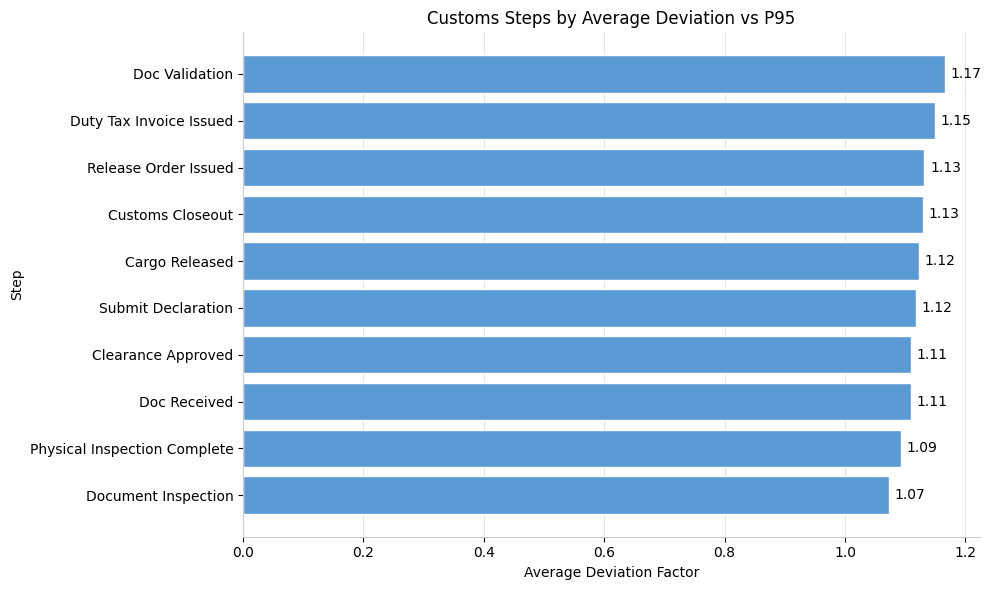

Saved: D:\logistics_AI\reports\customs\customs_customs_steps_avg_deviation_p95.png


In [38]:
# CELL 16

customs_pattern = r"DECLAR|DOC|DOCUMENT|VALIDAT|AMEND|REVIEW|INSPECT|CUSTOMS|DUTY|TAX|RELEASE|CLEARANCE"

step_deviation_df = (
    results_df.groupby("top_step_name")
    .agg(
        case_count=("case_id", "count"),
        avg_deviation_p95=("top_step_deviation_p95", "mean"),
        avg_duration_min=("top_step_duration_min", "mean"),
    )
    .reset_index()
)

customs_step_deviation_df = step_deviation_df[
    step_deviation_df["top_step_name"].astype(str).str.contains(customs_pattern, case=False, regex=True)
].copy()

if customs_step_deviation_df.empty:
    customs_step_deviation_df = step_deviation_df.copy()

customs_step_deviation_df = customs_step_deviation_df[customs_step_deviation_df["case_count"] >= 10].copy()
customs_step_deviation_df["step_label"] = customs_step_deviation_df["top_step_name"].map(pretty_step_label)
customs_step_deviation_df = customs_step_deviation_df.sort_values("avg_deviation_p95", ascending=False)

display(customs_step_deviation_df)

plot_dev_df = customs_step_deviation_df.head(10).copy().sort_values("avg_deviation_p95", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    plot_dev_df["step_label"],
    plot_dev_df["avg_deviation_p95"],
    color="#5b9bd5",
    edgecolor="white",
)

ax.set_title("Customs Steps by Average Deviation vs P95")
ax.set_xlabel("Average Deviation Factor")
ax.set_ylabel("Step")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.01, bar.get_y() + bar.get_height() / 2, f"{w:.2f}", va="center", ha="left")

step_dev_path = REPORT_DIR / f"{PROCESS_KEY}_customs_steps_avg_deviation_p95.png"
save_and_show(fig, step_dev_path)

In [39]:
# CELL 17

score_col = "anomaly_score" if "anomaly_score" in results_df.columns else "raw_anomaly"

customs_pattern = r"DECLAR|DOC|DOCUMENT|VALIDAT|AMEND|REVIEW|INSPECT|CUSTOMS|DUTY|TAX|RELEASE|CLEARANCE"

customs_focus_df = results_df[
    results_df["top_step_name"].astype(str).str.contains(customs_pattern, case=False, regex=True)
].copy()

if len(customs_focus_df) >= 20:
    top_risky_cases_df = customs_focus_df.sort_values(
        ["risk_score", score_col], ascending=False
    ).head(20).copy()
else:
    top_risky_cases_df = results_df.sort_values(
        ["risk_score", score_col], ascending=False
    ).head(20).copy()

display(
    top_risky_cases_df[
        [
            "case_id",
            "risk_score",
            score_col,
            "overall_severity",
            "top_step_name",
            "top_step_deviation_p95",
            "top_step_duration_min",
            "top_step_zscore",
        ]
    ]
)

,case_id,risk_score,anomaly_score,overall_severity,top_step_name,top_step_deviation_p95,top_step_duration_min,top_step_zscore
2648,ORD_4399774767,100.0,0.638609,CRITICAL,STEP_002_DOC_VALIDATION,1.981,59.717,5.072
307,ORD_4024479908,99.0,0.625783,CRITICAL,STEP_013_CARGO_RELEASED,1.937,1183.617,5.243
593,ORD_3534250077,99.0,0.624075,CRITICAL,STEP_013_CARGO_RELEASED,2.233,1364.967,6.299
1678,ORD_9973000099,99.0,0.599021,CRITICAL,STEP_007_PHYSICAL_INSPECTION_COMPLETE,1.881,1915.483,5.263
337,ORD_6003586467,99.0,0.593793,CRITICAL,STEP_013_CARGO_RELEASED,2.356,1440.000,6.736
253,ORD_2256307830,99.0,0.592671,CRITICAL,STEP_004_SUBMIT_DECLARATION,1.760,88.133,4.636
2514,ORD_9730026919,99.0,0.591962,CRITICAL,STEP_012_RELEASE_ORDER_ISSUED,1.559,925.783,3.827
33,ORD_7510137831,99.0,0.590941,BOTTLENECK,STEP_006_DOCUMENT_INSPECTION,1.416,1440.000,3.497
2759,ORD_3424964033,99.0,0.589984,BOTTLENECK,STEP_006_DOCUMENT_INSPECTION,1.416,1440.000,3.497
3186,ORD_1231040481,99.0,0.588821,CRITICAL,STEP_011_CLEARANCE_APPROVED,1.644,968.667,4.209


In [40]:
# CELL 18

summary_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_validation_summary.csv", index=False)
experiment_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_experiment_results.csv", index=False)
results_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_case_level_results.csv", index=False)
top_risky_cases_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_top_risky_cases.csv", index=False)
step_deviation_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_top_step_avg_deviation.csv", index=False)

train_summary_path = REPORT_DIR / f"{PROCESS_KEY}_train_summary_snapshot.json"
with open(train_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_train_summary, f, ensure_ascii=False, indent=2)

generated_files = [
    REPORT_DIR / f"{PROCESS_KEY}_model_risk_overview.png",
    REPORT_DIR / f"{PROCESS_KEY}_severity_mix.png",
    REPORT_DIR / f"{PROCESS_KEY}_risk_band_distribution.png",
    REPORT_DIR / f"{PROCESS_KEY}_top_steps_avg_deviation_p95.png",
    REPORT_DIR / f"{PROCESS_KEY}_validation_summary.csv",
    REPORT_DIR / f"{PROCESS_KEY}_experiment_results.csv",
    REPORT_DIR / f"{PROCESS_KEY}_case_level_results.csv",
    REPORT_DIR / f"{PROCESS_KEY}_top_risky_cases.csv",
    REPORT_DIR / f"{PROCESS_KEY}_top_step_avg_deviation.csv",
    REPORT_DIR / f"{PROCESS_KEY}_train_summary_snapshot.json",
]

for f in generated_files:
    print(f.exists(), "-", f)

True - D:\logistics_AI\reports\customs\customs_model_risk_overview.png
False - D:\logistics_AI\reports\customs\customs_severity_mix.png
True - D:\logistics_AI\reports\customs\customs_risk_band_distribution.png
False - D:\logistics_AI\reports\customs\customs_top_steps_avg_deviation_p95.png
True - D:\logistics_AI\reports\customs\customs_validation_summary.csv
True - D:\logistics_AI\reports\customs\customs_experiment_results.csv
True - D:\logistics_AI\reports\customs\customs_case_level_results.csv
True - D:\logistics_AI\reports\customs\customs_top_risky_cases.csv
True - D:\logistics_AI\reports\customs\customs_top_step_avg_deviation.csv
True - D:\logistics_AI\reports\customs\customs_train_summary_snapshot.json


In [41]:
# CELL 19

generated_files = [
    REPORT_DIR / f"{PROCESS_KEY}_experiment_compare_high_risk_rate.png",
    REPORT_DIR / f"{PROCESS_KEY}_severity_mix.png",
    REPORT_DIR / f"{PROCESS_KEY}_risk_band_distribution.png",
    REPORT_DIR / f"{PROCESS_KEY}_top_bottleneck_steps_share.png",
    REPORT_DIR / f"{PROCESS_KEY}_top_steps_avg_deviation_p95.png",
    REPORT_DIR / f"{PROCESS_KEY}_validation_summary.csv",
    REPORT_DIR / f"{PROCESS_KEY}_experiment_results.csv",
    REPORT_DIR / f"{PROCESS_KEY}_case_level_results.csv",
    REPORT_DIR / f"{PROCESS_KEY}_top_step_case_share.csv",
    REPORT_DIR / f"{PROCESS_KEY}_top_risky_cases.csv",
    REPORT_DIR / f"{PROCESS_KEY}_top_step_avg_deviation.csv",
    REPORT_DIR / f"{PROCESS_KEY}_train_summary_snapshot.json",
]

for f in generated_files:
    print(f.exists(), "-", f)

True - D:\logistics_AI\reports\customs\customs_experiment_compare_high_risk_rate.png
False - D:\logistics_AI\reports\customs\customs_severity_mix.png
True - D:\logistics_AI\reports\customs\customs_risk_band_distribution.png
False - D:\logistics_AI\reports\customs\customs_top_bottleneck_steps_share.png
False - D:\logistics_AI\reports\customs\customs_top_steps_avg_deviation_p95.png
True - D:\logistics_AI\reports\customs\customs_validation_summary.csv
True - D:\logistics_AI\reports\customs\customs_experiment_results.csv
True - D:\logistics_AI\reports\customs\customs_case_level_results.csv
False - D:\logistics_AI\reports\customs\customs_top_step_case_share.csv
True - D:\logistics_AI\reports\customs\customs_top_risky_cases.csv
True - D:\logistics_AI\reports\customs\customs_top_step_avg_deviation.csv
True - D:\logistics_AI\reports\customs\customs_train_summary_snapshot.json
